# CineMetrics — Insights & Conclusions

## Section 1 — Project Overview

CineMetrics is an end-to-end data analytics project exploring 
patterns and insights hidden within the IMDB Top 1000 rated films 
of all time. The goal is to go beyond surface level ratings and 
understand what truly defines a successful and well regarded film.

## Dataset
- **Source** — Kaggle (IMDB Top 1000 Movies Dataset)
- **File** — imdb-top-1000.csv
- **Size** — 1000 films × 10 features
- **Coverage** — Films released between 1920 and 2020

## Business Questions
- Do higher rated films earn more at the box office?
- Do audiences and critics agree on what makes a great film?
- Which genre dominates the IMDB Top 1000?
- Does the number of votes influence a film's box office earnings?
- How has cinema quality and earnings evolved across decades?

## Tools & Libraries
- **Data Manipulation** — Pandas, NumPy
- **Visualization** — Matplotlib, Seaborn
- **Environment** — Jupyter Notebook

## Section 2 — Key Findings

### Finding 1 - Drama Dominates

 - Drama is the most represented genre in IMDB Top 1000 with **289 Films**
 - Drama is nearly 3x more than the Action(172) and Comedy(155)
 - Thus the audience likes **Dramatic Story** with the cinematic excellence

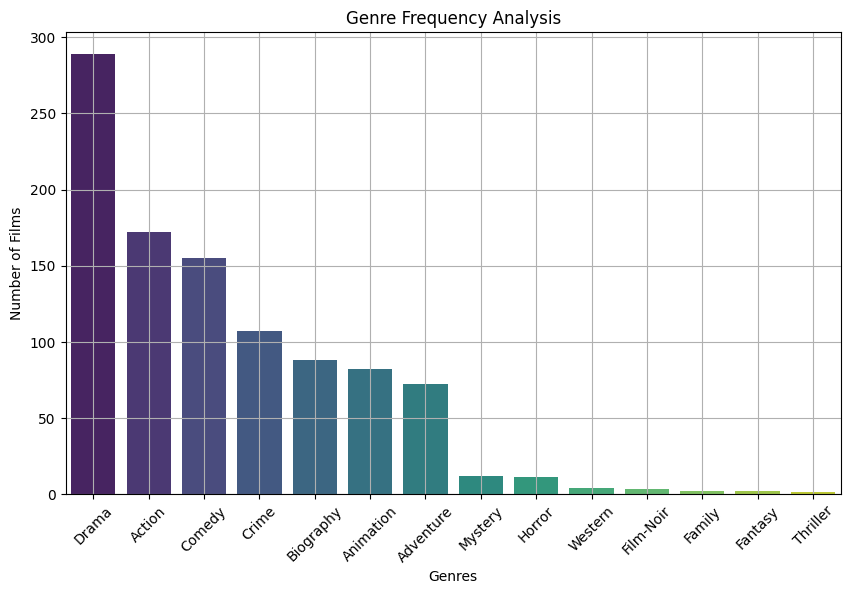

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df=pd.read_csv('../data/imdb-cleaned.csv')

temp=df.groupby('Genres')['Name'].count().sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=temp.index,y=temp.values,hue=temp.index,palette='viridis')
plt.xlabel('Genres')
plt.ylabel('Number of Films')
plt.title('Genre Frequency Analysis')
plt.xticks(rotation=45)
plt.ylim()
plt.grid()
plt.savefig('../images/genre_frequency.png', dpi=150, bbox_inches='tight')

plt.show()


### Finding 2 - Quality does not guarantee commercial success

- Higher IMDB shows **weak correlation** with box office gross
- **The Shawshank Redemption (IMDB=9.3)** earned only 28M $
- Several film less than IMDB 7.6 grossed over **800M+ $**

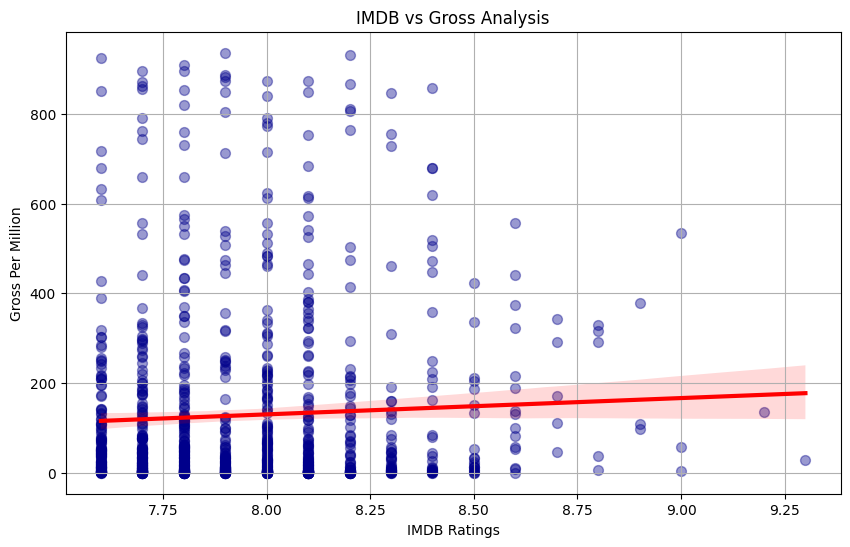

In [19]:
plt.figure(figsize=(10,6))

sns.regplot(data=df,x='IMDB',y='Gross_per_M',scatter_kws={'color':'darkblue','s':50,'alpha':0.4},line_kws={'color':'red','linewidth':3})
plt.xlabel('IMDB Ratings')
plt.ylabel('Gross Per Million')
plt.title('IMDB vs Gross Analysis')
plt.grid()
plt.savefig('../images/imdb_gross.png', dpi=150, bbox_inches='tight')

plt.show()

### Finding 3 - Survivorship bias in older decades

- **2020** contain only 6 number of movies 
- **1920** have total 11 number of films instead they have high IMDB Rating because they are the absolute best
- **Fewer films= Highest average= Survivorship bias**

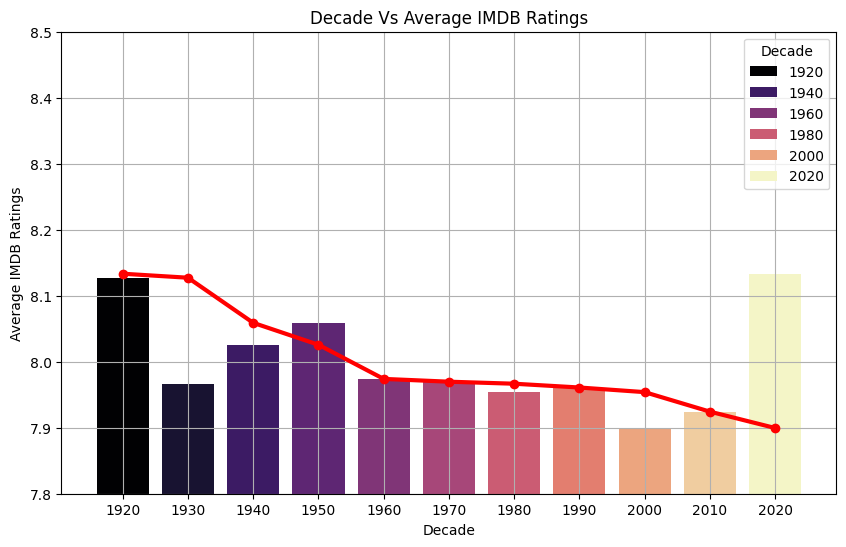

In [18]:
plt.figure(figsize=(10,6))
imdb_dec=df.groupby('Decade')['IMDB'].mean().sort_values(ascending=False)
sns.barplot(x=imdb_dec.index,y=imdb_dec.values,hue=imdb_dec.index,palette='magma')
plt.plot(range(len(imdb_dec)),imdb_dec.values,color='red',linewidth=3,marker='o')
plt.xlabel('Decade')
plt.ylabel('Average IMDB Ratings')
plt.title('Decade Vs Average IMDB Ratings')
plt.ylim(7.8,8.5)
plt.grid()
plt.savefig('../images/decade_imdb.png', dpi=150, bbox_inches='tight')

plt.show()

### Finding 4 - Modern decades dominate quantity
- **2020** have the highest earning but it contain only the **6** number of films so the analysis is somehow incomplete
- **1920** having the highest IMDB rating have best metascore but earning is less than 100M with contribution of only **11 Films**
- **2000s** and **2010s** together account for nearly **480 out of 
1000 films** — almost half the entire dataset.

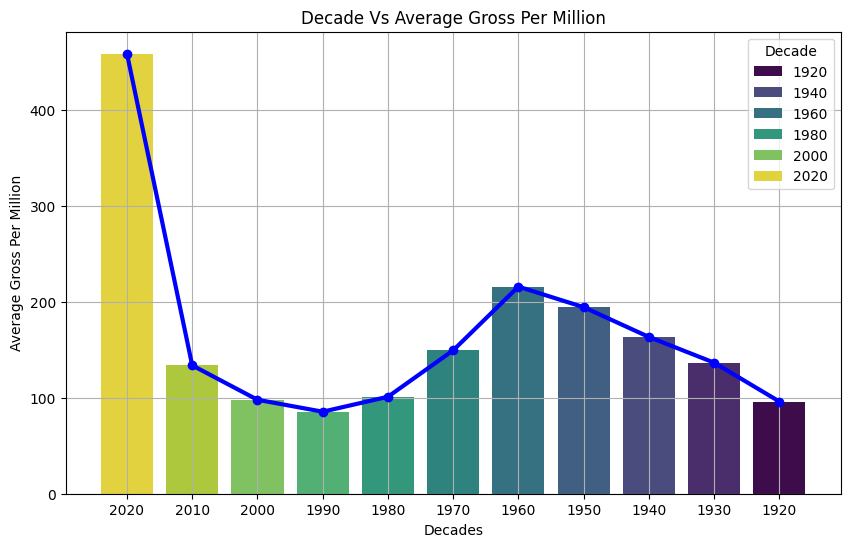

In [17]:
plt.figure(figsize=(10,6))
dec_gross=df.groupby('Decade')['Gross_per_M'].mean().sort_index(ascending=False)
sns.barplot(x=dec_gross.index,y=dec_gross.values,palette='viridis',hue=dec_gross.index,order=dec_gross.index,hue_order=dec_gross.index)
plt.plot(range(len(dec_gross)),dec_gross.values,color='blue',linewidth=3,marker='o')
plt.xlabel('Decades')
plt.ylabel('Average Gross Per Million')
plt.title('Decade Vs Average Gross Per Million')

plt.grid()
plt.savefig('../images/decade_average01.png', dpi=150, bbox_inches='tight')


plt.show()

### Finding 5 — Critics and audiences mostly agree

- **IMDB rating** and **Metascore** show a **moderate positive 
correlation** — as audience ratings increase, critic scores 
broadly follow the same trend. 
- However the wide spread of dots reveals significant outliers — films where audiences and critics strongly disagree are the most interesting stories in the dataset.

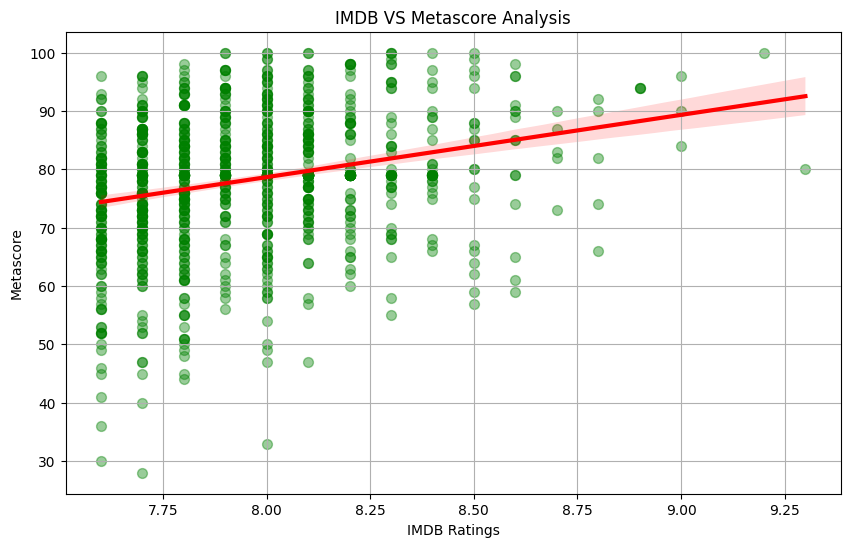

In [21]:
plt.figure(figsize=(10,6))
sns.regplot(data=df,x='IMDB',y='Metascore',
            scatter_kws={'color':'green','s':50,'alpha':0.4},
            line_kws={'color':'red','linewidth':3}
        )

plt.xlabel('IMDB Ratings')
plt.ylabel('Metascore')
plt.title('IMDB VS Metascore Analysis')
plt.grid()
plt.savefig('../images/imdb_metascore.png', dpi=150, bbox_inches='tight')

plt.show()

### Finding 6 — 2020s gross is misleading

- The 2020s decade shows the highest average gross at 450M+ but with 
only 6 films in the dataset this figure is statistically unreliable. 
- Any decade level gross comparison should exclude 2020s or treat it 
as an incomplete sample.

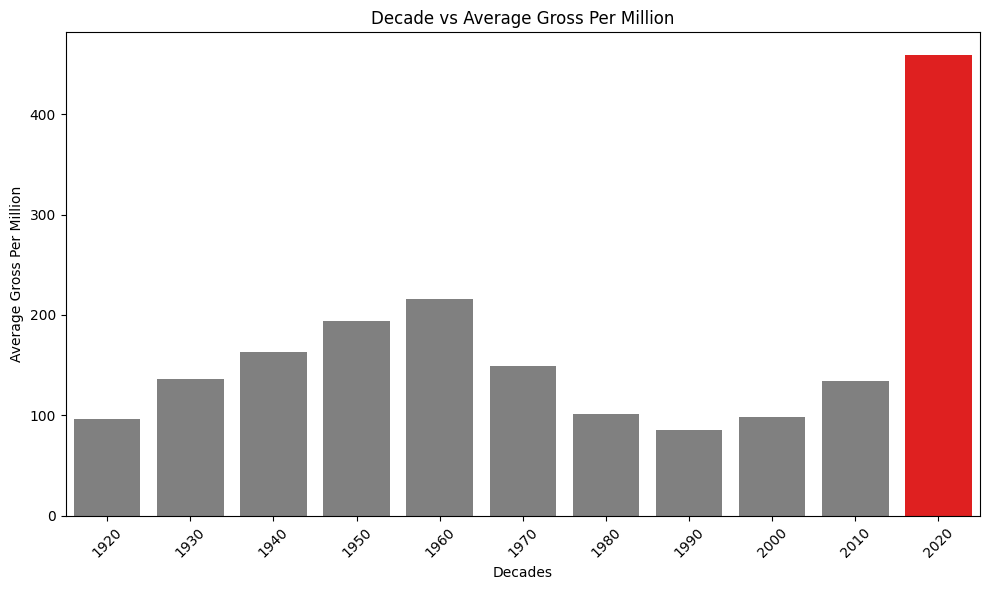

In [16]:
film_conclusion = df.groupby('Decade')['Gross_per_M'].mean().sort_index()
palettes = {decade: 'red' if decade == 2020 else 'grey'
           for decade in film_conclusion.index}
plt.figure(figsize=(10,6))
sns.barplot(x=film_conclusion.index, y=film_conclusion.values,hue=film_conclusion.index,order=film_conclusion.index,hue_order=film_conclusion.index, palette=palettes,legend=None)
plt.xlabel('Decades')
plt.ylabel('Average Gross Per Million')
plt.title('Decade vs Average Gross Per Million')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Section 3 — Recommendations

**Recommendation 1 — Invest in Drama for critical acclaim**
Studios aiming for long term critical recognition should prioritize 
Drama productions. With 289 films in the IMDB Top 1000 Drama has 
consistently proven to be the genre most associated with cinematic 
excellence in the eyes of audiences worldwide.

**Recommendation 2 — Do not rely on ratings alone for box office strategy**
IMDB rating is a poor predictor of commercial success. Studios and 
distributors should focus on genre, franchise value, and marketing 
budget rather than chasing critical ratings to maximize box office 
earnings.

**Recommendation 3 — Apply survivorship bias correction in historical analysis**
Any analysis comparing older decades to modern ones should account 
for survivorship bias. Only truly exceptional classic films appear 
in the top 1000 — making direct quality comparisons across decades 
misleading without this context.

**Recommendation 4 — Treat IMDB rankings as recency biased**
IMDB rankings heavily favor modern films due to a larger and younger 
voter base. Analysts should not interpret decade dominance as a 
measure of film quality but rather as a reflection of voter 
demographics and film availability.

**Recommendation 5 — Target both audiences and critics simultaneously**
Since IMDB ratings and Metascore show moderate positive correlation, 
filmmakers do not have to choose between critical and audience appeal. 
Investing in quality storytelling tends to satisfy both groups 
simultaneously.

**Recommendation 6 — Exclude incomplete decades from gross analysis**
The 2020s should be excluded from any decade level gross comparison 
until the decade is complete. Future analysis should also adjust all 
gross figures for inflation to make earnings comparable across 
different eras of cinema.

## Section 4 — Limitations

**Limitation 1 — Dataset scope is restricted**
This analysis covers only the IMDB Top 1000 rated films and is 
not representative of all cinema. Conclusions drawn here apply 
exclusively to highly rated films and should not be generalized 
to the broader film industry.

**Limitation 2 — Gross earnings not adjusted for inflation**
All box office gross figures are in raw historical dollars and 
have not been adjusted for inflation. A film earning $50M in 1970 
represents far greater commercial success than the same amount 
earned in 2010 — making direct decade comparisons potentially 
misleading.

**Limitation 3 — Only one lead star captured per film**
The dataset captures only the primary lead star per film. Many 
successful films have ensemble casts where multiple stars 
contribute equally to commercial and critical success — this 
analysis cannot capture that complexity.

**Limitation 4 — Missing Metascore values**
157 out of 1000 films had no Metascore recorded. These were 
filled using the column median which introduces slight statistical 
bias into any analysis involving Metascore. Results involving 
this column should be interpreted with appropriate caution.

**Limitation 5 — 2020s decade is incomplete**
The 2020s are represented by only 6 films in the dataset making 
it statistically unreliable for any decade level comparison. 
All 2020s findings should be treated as preliminary and 
revisited when more complete data becomes available.